<br>
<html>
  <body>
    <header></header>
        <CENTER>
          <img src="https://uvv.br/wp-content/themes/core/dist/images/Logo@2x.png" alt="UVV-LOGO" style = width="100px"; height="100px">
        </CENTER>
        <CENTER><b>ANÁLISE EXPLORATÓRIA DOS DADOS</b></CENTER>
        <CENTER><b>ANÁLISE QUALITATIVA</b></CENTER>
        </font>
  </body>
</html>

**NOME:** Isabela Carone Lacerda


**LINK PARA ESTE NOTEBOOK:** [Aqui!]()

# BIBLIOTECAS E FUNÇÕES

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import os

##LOAD

In [2]:
# LOAD DO DATASET
table = pd.read_csv('/content/table16.csv', index_col=0) # vira df aqui

In [3]:
from google.colab import drive
drive.mount('/content/drive')

path = '/content/drive/MyDrive/Sistemas-de-Informacao/6-periodo-2026.1/Estatistica-para-Ciencia-de-Dados-40h/Exercicios'
print(os.listdir(path))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['atividade1.ipynb', 'atividade1.html']


In [4]:
print(type(table))

<class 'pandas.core.frame.DataFrame'>


### TABELA DE DISCRETIZAÇÃO: DICIONÁRIOS DE MAPEAMENTO (Label Mapping)

<center>

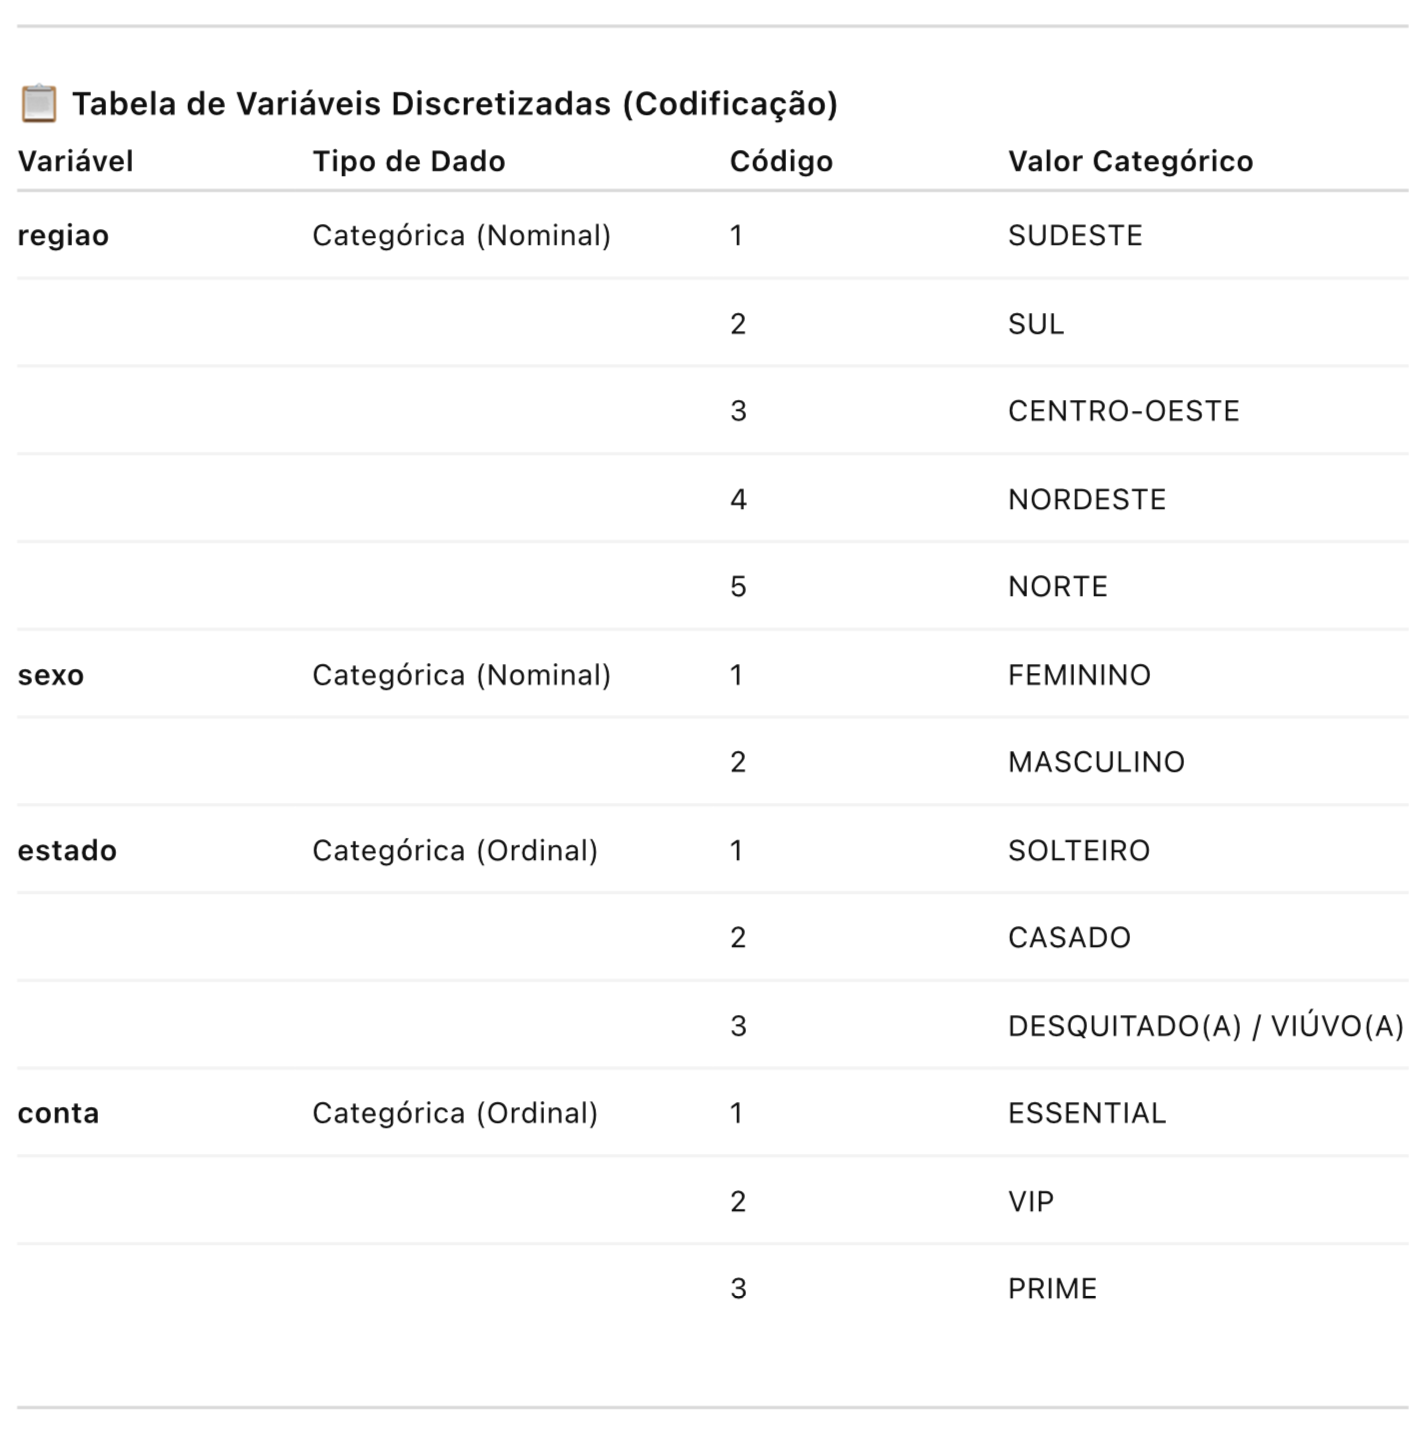

In [5]:
table.head()

,NOTA FISCAL,REGIÃO,SEXO,ESTADO CIVIL,DEPENDENTES,RENDA BRUTO (R$),OPINIÃO DO CLIENTE,NOTA DE SATISFAÇÃO (%),MEAN: alcohol,MEAN: malic_acid,...,MEAN: total_phenols,MEAN: flavanoids,MEAN: nonflavanoid_phenols,MEAN: proanthocyanins,MEAN: color_intensity,MEAN: hue,MEAN: od280/od315_of_diluted_wines,MEAN: proline,TIPO DA CONTA,TOTAL (R$)
0,6876333,SUL,MASCULINO,SOLTEIRO,1,3336.84,"Serviço eficiente, recomendo o clube: UVVine",68.680,12.929435,2.447630,...,1.334842,2.236478,0.290384,1.661732,7.833947,0.952735,3.818190,276.681180,ESSENTIAL,302.31
1,5677339,SUDESTE,MASCULINO,CASADO,2,3453.34,"Serviço eficiente, recomendo o clube: UVVine",68.680,13.993214,1.393874,...,1.475983,1.676041,0.385297,1.940256,2.139143,0.910653,3.042307,377.891615,ESSENTIAL,278.26
2,1104271,SUDESTE,FEMININO,SOLTEIRO,1,3211.29,"Serviço impecável, adorei o clube: UVVine",68.680,11.161985,3.471322,...,0.820464,2.363073,0.264392,1.617888,4.953122,1.120121,3.019603,709.736181,ESSENTIAL,580.02
3,2691016,SUL,FEMININO,CASADO,1,26192.61,"Serviço eficiente, recomendo o clube: UVVine",77.972,13.361280,1.463516,...,1.991469,0.235816,0.607276,0.835639,3.284154,1.078509,1.955873,994.797550,PRIME,3930.88
4,6636530,CENTRO-OESTE,MASCULINO,SOLTEIRO,1,21792.17,Entrega foi boa e rápida na UVVine,68.680,13.536534,3.832572,...,2.269030,1.487258,0.222171,1.445279,4.178987,0.988953,1.591512,377.293171,PRIME,873.68


In [6]:
table.shape

(1120000, 23)

## FAZER AS QUESTÕES AQUI:

In [7]:
def identify_variables_types(
    df : pd.DataFrame
) -> pd.DataFrame:
  """
  Classifica as colunas do dataset em: númericas,

  """
  summary = []

  # loop p todos os itens da coluna e quais são únicos, também há uma contagem para os nulos
  for col in df.columns:
    dtype = df[col].dtype
    unique_count = df[col].nunique()
    null_count = df[col].isnull().sum()

  if unique_count == 2:
    classification = 'binary'
  elif pd.api.types.is_numeric_dtype(df[col]):
    if unique_count < 15:
      classification = 'numeric - discrete'
    else:
      classification = 'numeric - continuous'
  elif pd.api.types.is_datetime64_any_dtype:
    classification = 'temporal'
  else:
    classification = 'categorical'

  # saída

  summary.append({
      'column': col,
      'dtype': dtype,
      'unique_count': unique_count,
      'null_count': null_count,
      'classification': classification
  })

  return pd.DataFrame(summary)

In [8]:
def plot_qualitative_pie_charts(
    df : pd.DataFrame
    ) -> None:
    """
    Gera análises gráficas por setor (pizza) para as variáveis qualitativas,
    utilizando a identidade visual e paletas de cores do Seaborn.

    Args:
        df (pd.DataFrame): O DataFrame contendo os dados.

    """
    # setando tema e cor
    sns.set_theme(style="whitegrid")
    colors = sns.color_palette("viridis")

    # list das colunas qualitativas
    qualitative_vars = ['REGIÃO', 'SEXO', 'ESTADO CIVIL']

    for col in qualitative_vars:
        if col in df.columns:
            data_counts = df[col].value_counts()

            # gerando o graf
            plt.figure(figsize=(8, 6))

            # usando matplob mas vou deixar a estetica meio seaborn
            plt.pie(
                data_counts,
                labels=data_counts.index,
                autopct='%1.1f%%',
                startangle=140,
                colors=colors,
                wedgeprops={'edgecolor': 'white', 'linewidth': 2}
                )


            plt.title(f'Análise por setor: {col}', fontsize=14, fontweight='bold', pad=20)

            plt.axis('equal')
            plt.show()
        else:
            print(f"Aviso: Coluna '{col}' não encontrada no dataset.")


# plot_qualitative_pie_charts(table)


In [9]:
def plot_bivariate_analysis(
    df : pd.DataFrame,
    qual1 : str,
    qual2 : str,
    quant : str
    ) -> None:
    """
    Exibe uma análise gráfica de barras comparando 2 variaveis qualitativas
    em relação a uma variavel quantitativa

    Args:
        df (pd.DataFrame): O dataset (table).
        qual1 (str): Nome da primeira variável qualitativa (eixo X).
        qual2 (str): Nome da segunda variável qualitativa (legenda/cores).
        quant (str): Nome da variável quantitativa (eixo Y).
    """
    # setando tema e cor
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 7))


    # x: categorias principais, y: o número que queremos comparar, hue: a subdiv
    ax = sns.barplot(
        data=df,
        x=qual1,
        y=quant,
        hue=qual2,
        palette="magma",
        errorbar=('ci', 95)
    )

    # formatacoes
    ax.set_title(f'Análise de {quant} por {qual1} e {qual2}', fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel(qual1, fontsize=12)
    ax.set_ylabel(f'Média de {quant}', fontsize=12)


    plt.legend(title=qual2, bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.show()

In [10]:
def plot_pareto_bivariate(
    df : pd.DataFrame,
    qual1 : str,
    qual2 : str,
    quant: str
    ) -> None:
    """
    Exibe um gráfico de Pareto comparando a soma de uma variável quantitativa
    pelo cruzamento de duas variáveis qualitativas.

    Args:
        df (pd.DataFrame): O dataset original.
        qual1 (str): Primeira variável qualitativa.
        qual2 (str): Segunda variável qualitativa.
        quant (str): Variável quantitativa (ex: Renda ou Faturamento).
    """
    # agrupando e sum
    df_pareto = df.groupby([qual1, qual2])[quant].sum().reset_index()
    df_pareto['combinacao'] = df_pareto[qual1] + " + " + df_pareto[qual2]

    df_pareto = df_pareto.sort_values(by=quant, ascending=False).reset_index(drop=True)

    # Calcular porcentagem acumulada
    df_pareto['cum_percentage'] = 100 * df_pareto[quant].cumsum() / df_pareto[quant].sum()

    # setando tema
    sns.set_theme(style="white")
    fig, ax1 = plt.subplots(figsize=(14, 7))

    # graf de barras
    sns.barplot(
        data=df_pareto,
        x='combinacao',
        y=quant,
        palette="flare",
        ax=ax1
    )
    ax1.set_ylabel(f'Soma de {quant}', fontsize=12, fontweight='bold')
    ax1.set_xlabel(f'Cruzamento: {qual1} e {qual2}', fontsize=12)
    plt.xticks(rotation=45, ha='right')

    # graf linha acum
    ax2 = ax1.twinx()
    sns.lineplot(
        data=df_pareto,
        x='combinacao',
        y='cum_percentage',
        color='black',
        marker='D',
        ax=ax2,
        sort=False
    )

    # ajustes no pareto
    ax2.axhline(80, color='red', linestyle='--', alpha=0.6)
    ax2.set_ylabel('Porcentagem Acumulada (%)', fontsize=12, fontweight='bold')
    ax2.set_ylim(0, 110)

    plt.title(f'Gráfico de Pareto: {quant} por {qual1} e {qual2}', fontsize=16, pad=20)
    plt.show()

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_all_paretos(
    df : pd.DataFrame
    ) -> None:
    """
    Identifica variáveis qualitativas e gera um gráfico de Pareto para cada uma,
    mostrando a frequência absoluta e a porcentagem acumulada.
    """
    # setando tema
    sns.set_theme(style="white")

    qual_cols = [col for col in df.columns if df[col].dtype == 'object' and df[col].nunique() <= 15]

    for col in qual_cols:
        # count e ordenacao
        data = df[col].value_counts().reset_index()
        data.columns = [col, 'count']
        data['cum_perc'] = 100 * data['count'].cumsum() / data['count'].sum()


        fig, ax1 = plt.subplots(figsize=(12, 6))

        # barras de freq
        sns.barplot(data=data, x=col, y='count', palette="viridis", ax=ax1)
        ax1.set_title(f'Gráfico de Pareto: {col}', fontsize=16, fontweight='bold')
        ax1.set_ylabel('Frequência Absoluta')

        ax2 = ax1.twinx()
        sns.lineplot(data=data, x=col, y='cum_perc', color='red', marker='o', ax=ax2, sort=False)


        ax2.axhline(80, color='orange', linestyle='--', label='80%')
        ax2.set_ylabel('Porcentagem Acumulada (%)')
        ax2.set_ylim(0, 110)

        plt.tight_layout()
        plt.show()


In [12]:



def analyze_cross_tabulation(
    df : pd.DataFrame,
    qual1 : str,
    qual2 : str
    ) -> None:
    """
    Exibe a tabulação cruzada e gera gráficos de setores com valores
    absolutos e relativos para o cruzamento de duas variáveis.

    Args:
        df (pd.DataFrame): O dataset de entrada (table).
        qual1 (str): Variável que define os grupos (ex: 'REGIÃO').
        qual2 (str): Variável que será contada dentro dos grupos (ex: 'SEXO').
    """

    ct = pd.crosstab(df[qual1], df[qual2])

    print(f"--- Tabulação Cruzada: {qual1} vs {qual2} ---")
    display(ct)

    print("\n")

    sns.set_theme(style="whitegrid")
    cols = ct.index

    for label in cols:
        data = ct.loc[label]


        plt.figure(figsize=(8, 6))

        # func p valor rrelativo e absoluto
        def func(pct, allvals):
            absolute = int(round(pct/100.*sum(allvals)))
            return f"{pct:.1f}%\n({absolute:d} un)"

        # plot da pizza
        plt.pie(
            data,
            labels=data.index,
            autopct=lambda pct: func(pct, data),
            startangle=140,
            colors=sns.color_palette("Set2"),
            wedgeprops={'edgecolor': 'white', 'linewidth': 2}
        )

        plt.title(f'Distribuição de {qual2} em: {label}', fontsize=14, fontweight='bold')
        plt.axis('equal')
        plt.show()


In [13]:
def analyze_groupby_cross_distribution(
    df : pd.DataFrame,
    qual1 : str,
    qual2 : str
    ) -> None:
    """
    Exibe a tabulação cruzada usando GROUPBY e gera gráficos de setores
    com valores absolutos e porcentagens.

    Args:
        df (pd.DataFrame): O dataset (table).
        qual1 (str): Variável de agrupamento principal (ex: 'ESTADO CIVIL').
        qual2 (str): Variável para detalhamento (ex: 'REGIÃO').
    """

    ct_groupby = df.groupby([qual1, qual2]).size().unstack(fill_value=0)

    print(f"--- Tabulação Cruzada (via Groupby): {qual1} vs {qual2} ---")
    display(ct_groupby)
    print("\n")


    sns.set_theme(style="whitegrid")

    for category in ct_groupby.index:
        data = ct_groupby.loc[category]

        # fun p calcular absoluto e relativo p pizza
        def make_autopct(values):
            def my_autopct(pct):
                total = sum(values)
                val = int(round(pct*total/100.0))
                return f'{pct:.1f}%\n({val:d})'
            return my_autopct

        plt.figure(figsize=(8, 6))
        plt.pie(
            data,
            labels=data.index,
            autopct=make_autopct(data),
            startangle=140,
            colors=sns.color_palette("husl", len(data)),
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
        )

        plt.title(f'Distribuição de {qual2} para: {category}', fontsize=14, fontweight='bold')
        plt.axis('equal')
        plt.show()

#Questão 1:

Faça uma **Função Genérica** (**def + docstring**) que crie um **dataframe** com a classificação dos tipos de variáveis do dataset:

In [14]:
#chamar somente a resposta aqui:
identify_variables_types(table)

,column,dtype,unique_count,null_count,classification
0,TOTAL (R$),float64,248228,0,numeric - continuous


#Questão 2:

Faça uma **Função Genérica**  (**def + docstring**) que exiba a análise gráfica por setor de todas as variáveis qualitativa do seu dataset:

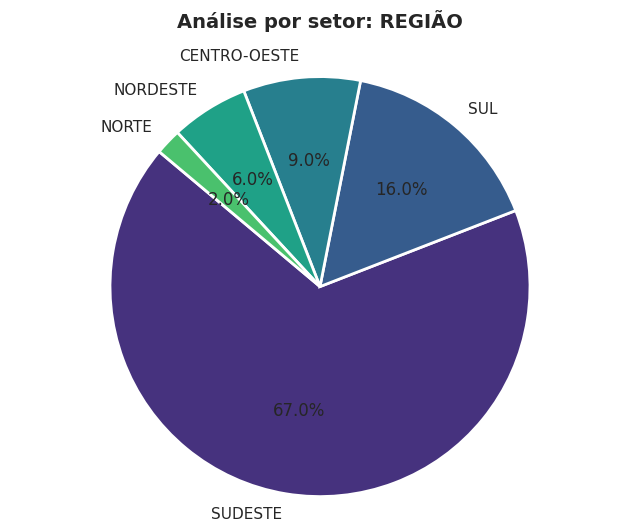

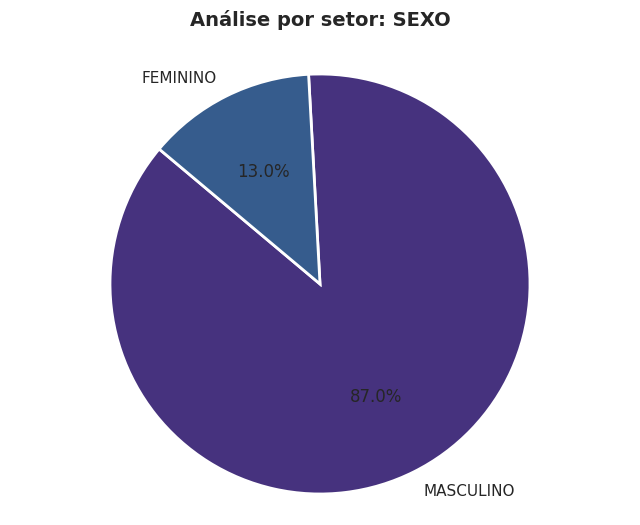

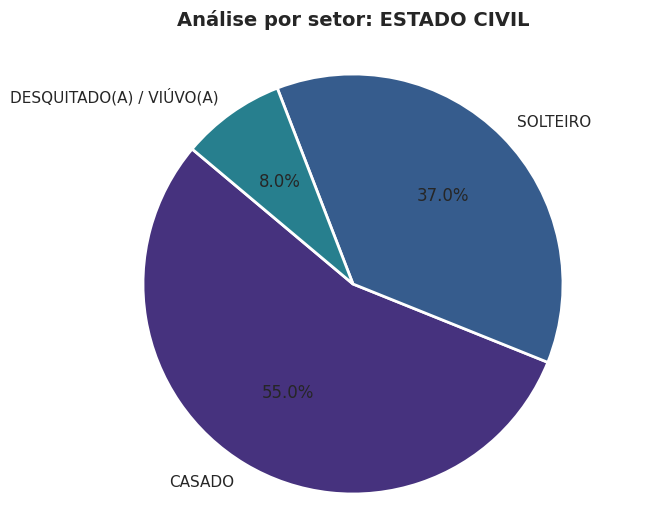

In [15]:
plot_qualitative_pie_charts(table)

#Questão 3:

Faça uma **Função Genérica**  (**def + docstring**) que exiba a análise gráfica de barras de duas (2) variáveis qualitativas por uma (1) quantitativa do seu dataset:

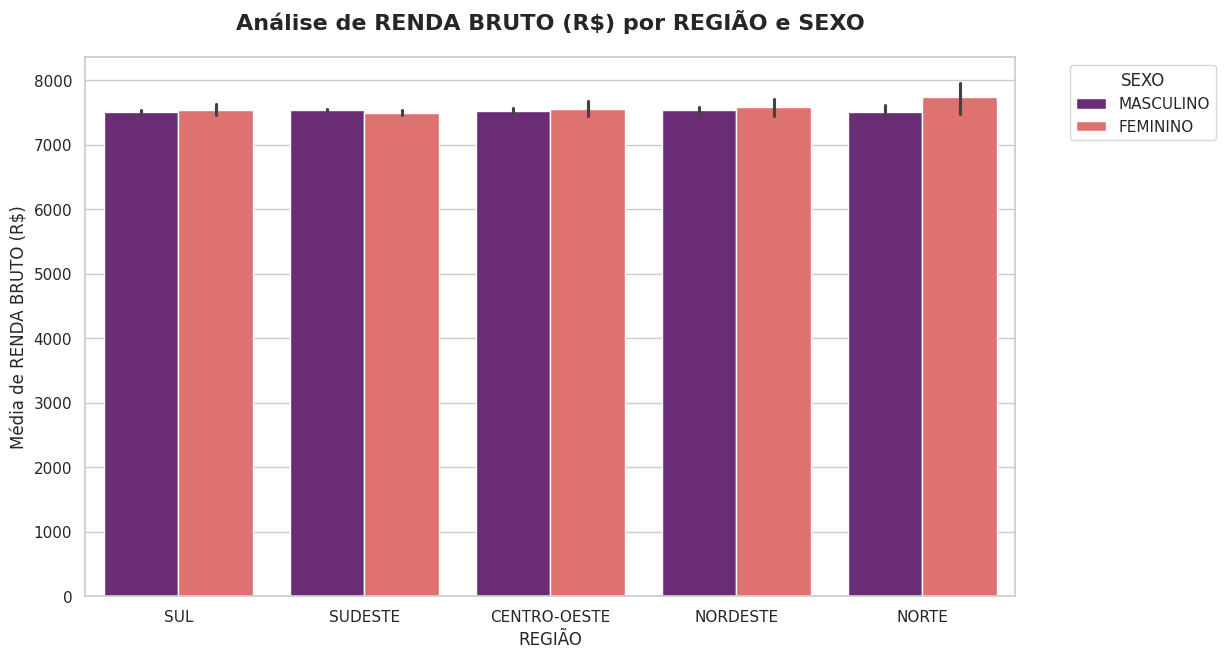

In [16]:
plot_bivariate_analysis(table, 'REGIÃO', 'SEXO', 'RENDA BRUTO (R$)')

#Questão 4:

Faça uma **Função Genérica**  (**def + docstring**) que exiba a análise gráfica de pareto de duas (2) variáveis qualitativas por uma (1) quantitativa do seu dataset:

/tmp/ipython-input-1405488067.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


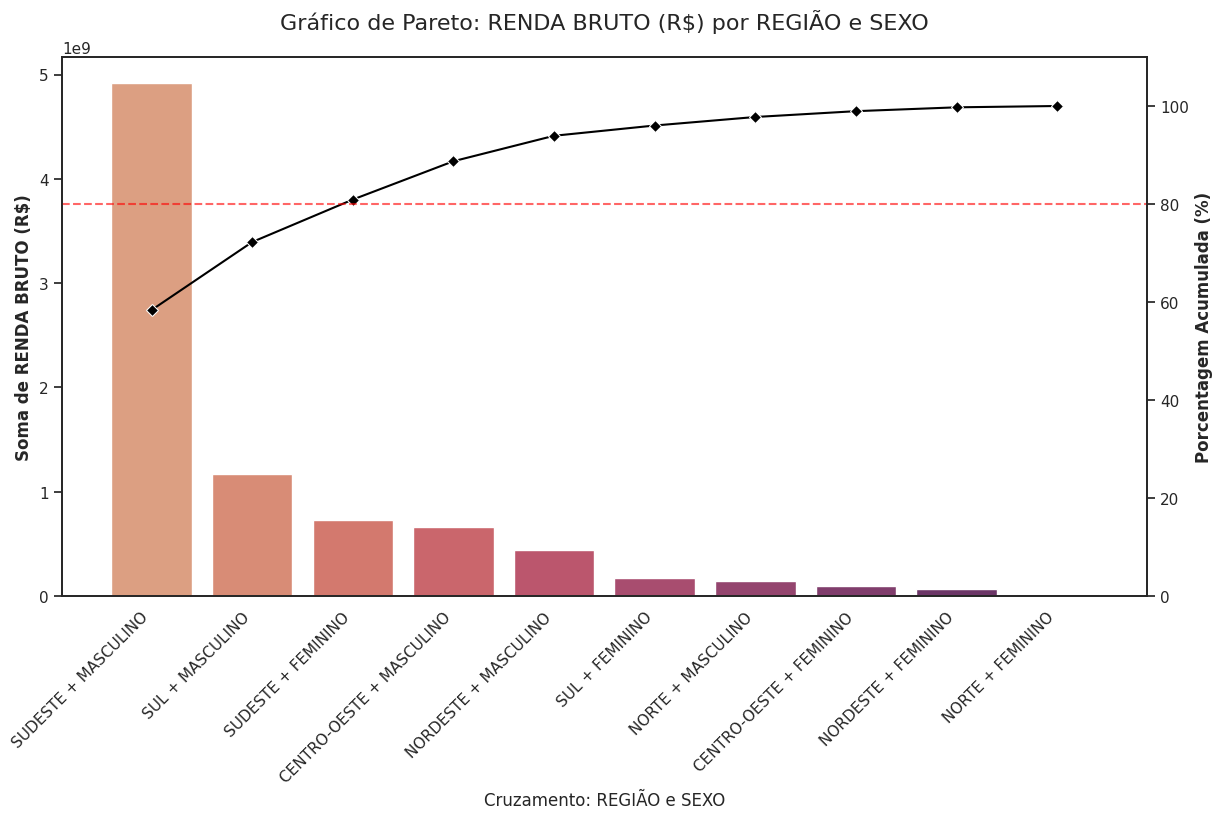

In [17]:
plot_pareto_bivariate(table, 'REGIÃO', 'SEXO', 'RENDA BRUTO (R$)')

#Questão 5:

Faça uma **Função Genérica**  (**def + docstring**) de pareto e aplique a todas as variáveis quanlitativas do seu dataset:

/tmp/ipython-input-2458108423.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x=col, y='count', palette="viridis", ax=ax1)


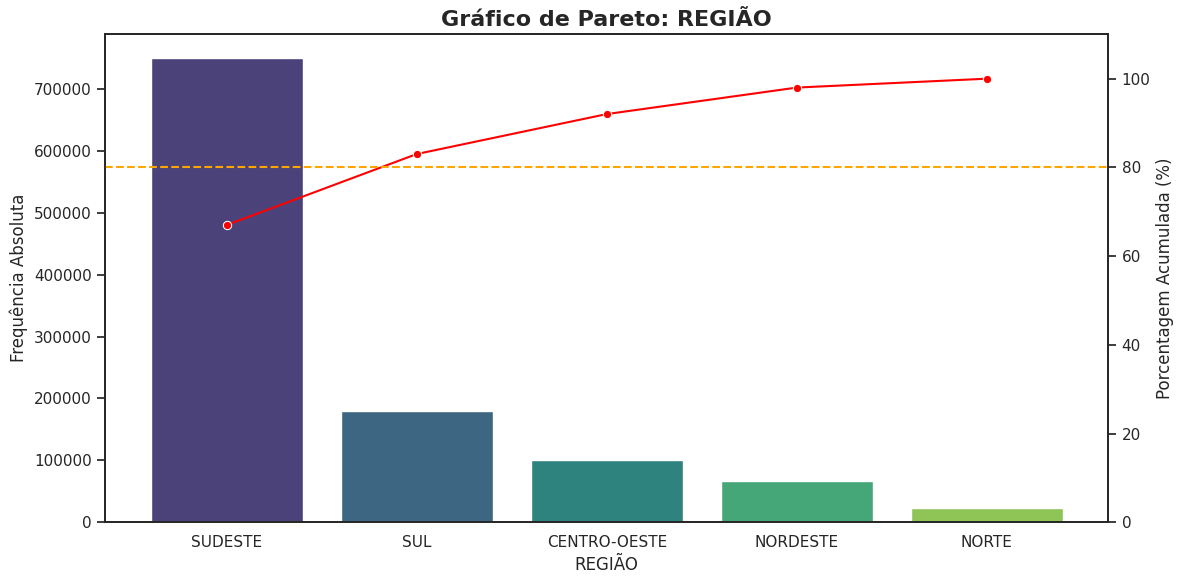

/tmp/ipython-input-2458108423.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x=col, y='count', palette="viridis", ax=ax1)


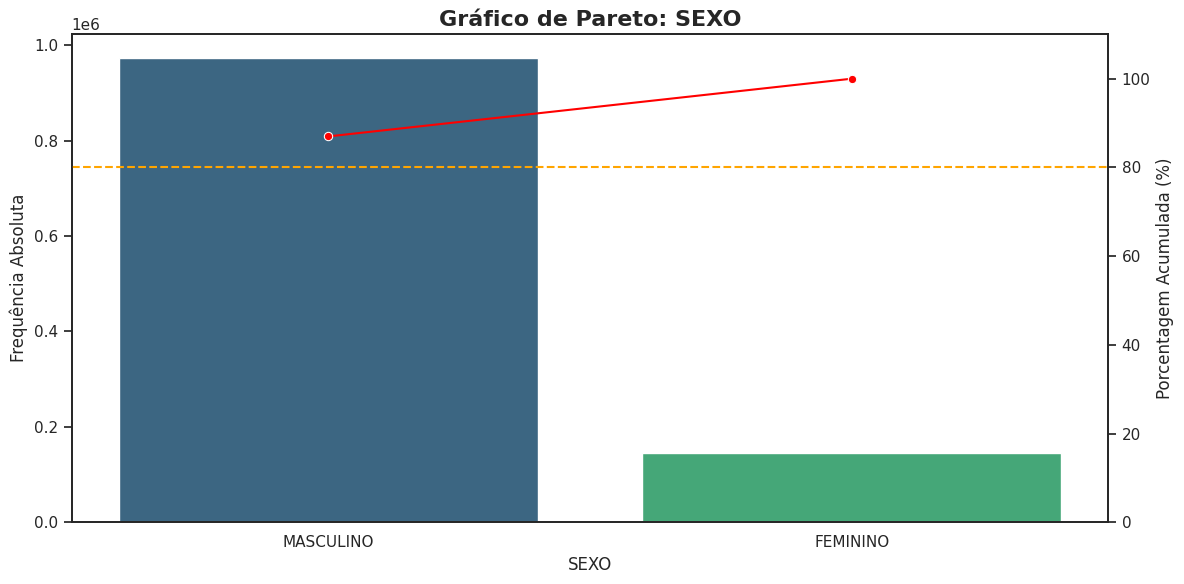

/tmp/ipython-input-2458108423.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x=col, y='count', palette="viridis", ax=ax1)


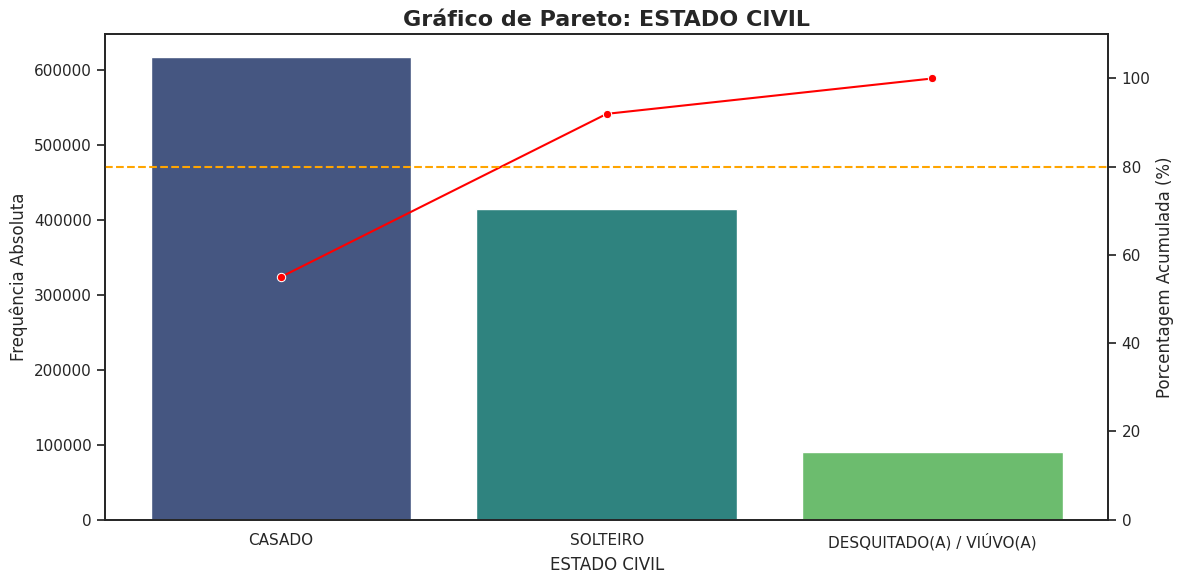

/tmp/ipython-input-2458108423.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x=col, y='count', palette="viridis", ax=ax1)


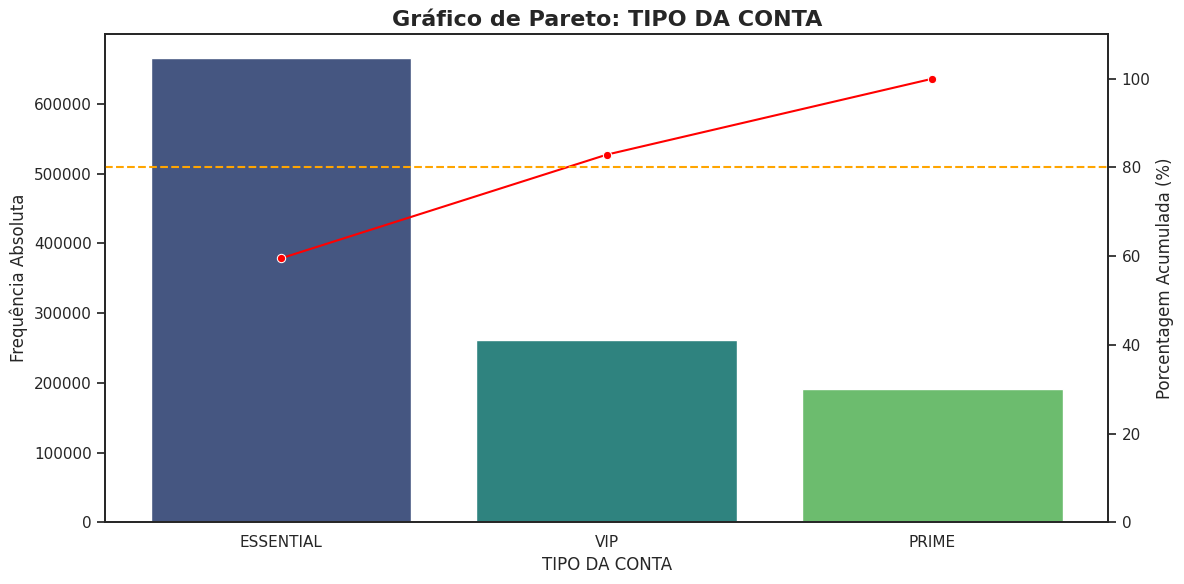

In [18]:
plot_all_paretos(table)

#Questão 6:

Faça uma função **Função Genérica** que exiba a tabulação cruzada (**comando: cross table**) duas (2) variáveis qualitativas do seu dataset:

Com essas variáveis, faça também um gráfico de setor com os valores absolutos e relativos(%) destas categorias.

--- Tabulação Cruzada: REGIÃO vs SEXO ---


SEXO,FEMININO,MASCULINO
REGIÃO,,
CENTRO-OESTE,13286,87611
NORDESTE,8723,58191
NORTE,2927,19505
SUDESTE,97512,653012
SUL,23387,155846


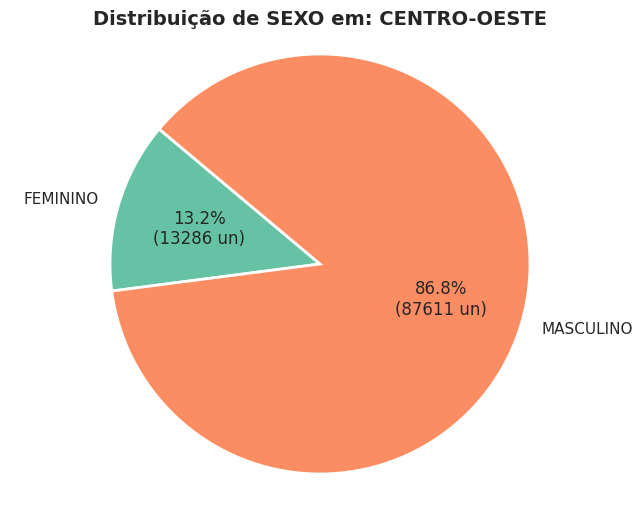

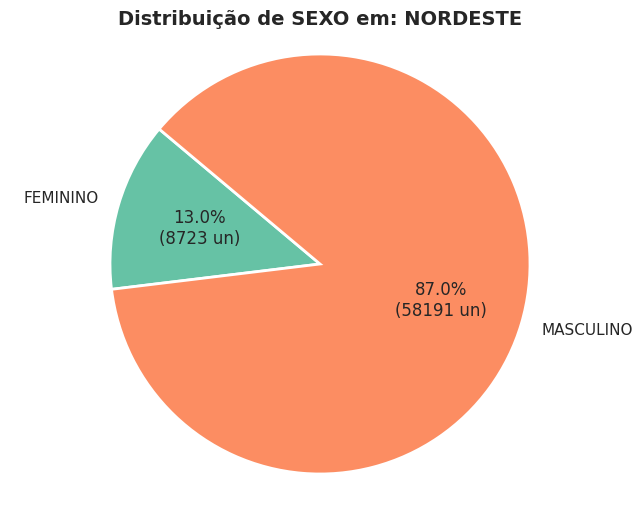

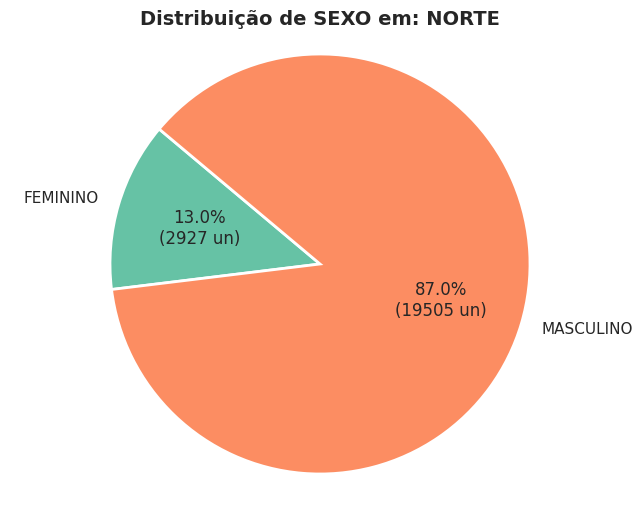

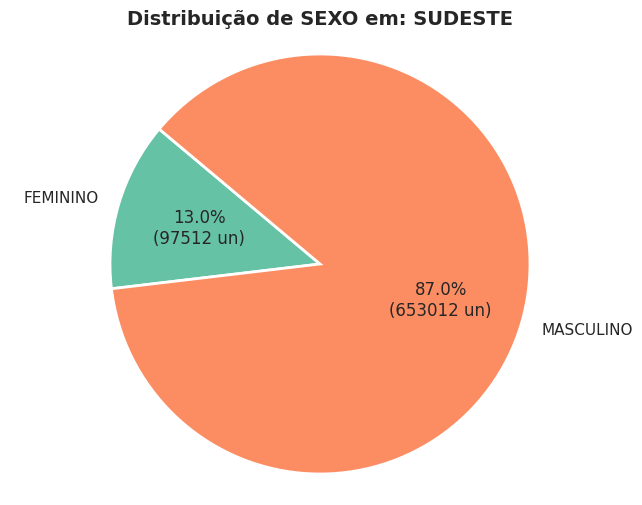

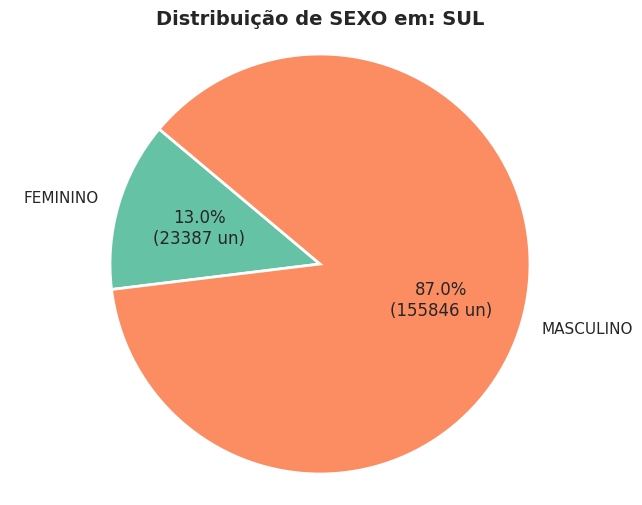

In [19]:
analyze_cross_tabulation(table, 'REGIÃO', 'SEXO')

#Questão 7:

Faça uma **Função Genérica** (**def + docstring**) que exiba a tabulação cruzada (**comando: group by**) duas (2) variáveis qualitativas do seu dataset (pelo menos uma variável diferente das usadas na Questão 6):

Com essas variáveis, faça também um gráfico de setor com os valores absolutos e relativos(%) destas categorias.

--- Tabulação Cruzada (via Groupby): ESTADO CIVIL vs REGIÃO ---


REGIÃO,CENTRO-OESTE,NORDESTE,NORTE,SUDESTE,SUL
ESTADO CIVIL,,,,,
CASADO,55770,36931,12411,412835,98349
DESQUITADO(A) / VIÚVO(A),8095,5221,1795,60094,14596
SOLTEIRO,37032,24762,8226,277595,66288


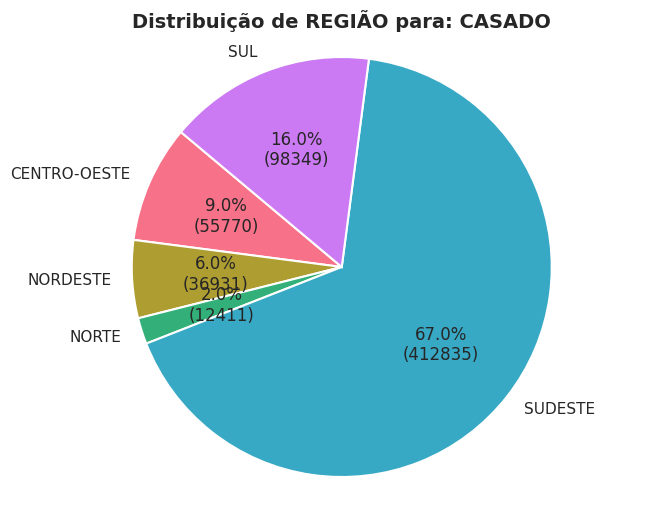

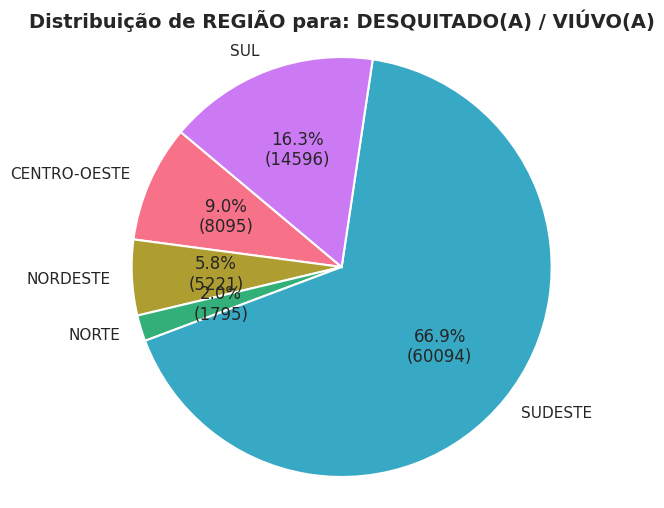

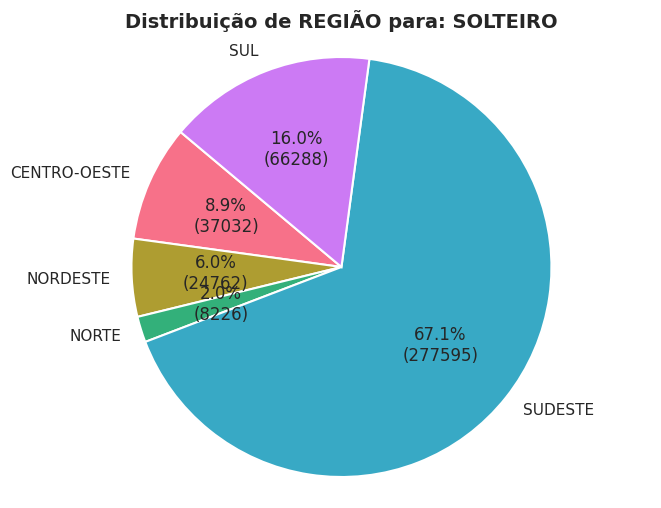

In [20]:
analyze_groupby_cross_distribution(table, 'ESTADO CIVIL', 'REGIÃO')

PARA ENTREGAR: Converter seu YPYNB para PDF:

In [23]:
import os

# 1. O teu caminho exato no Drive
path_exercicios = '/content/drive/MyDrive/Sistemas-de-Informacao/6-periodo-2026.1/Estatistica-para-Ciencia-de-Dados-40h/Exercicios'

# 2. Localizar o ficheiro .ipynb nessa pasta
arquivos = [f for f in os.listdir(path_exercicios) if f.endswith('.ipynb')]

if not arquivos:
    print("Nenhum ficheiro .ipynb encontrado na pasta de Exercícios.")
else:
    # Seleciona o ficheiro (se houver mais de um, ele pegará o primeiro da lista)
    nome_arquivo = arquivos[0]
    caminho_entrada = os.path.join(path_exercicios, nome_arquivo)

    print(f"A converter: {nome_arquivo}")
    print(f"Destino: {path_exercicios}")

    # 3. Executa a conversão definindo o output-dir para a mesma pasta do Drive
    # As aspas duplas são obrigatórias por causa dos espaços e hífens no caminho
    !jupyter nbconvert --to html "{caminho_entrada}" --output-dir="{path_exercicios}"

    print("\n✅ Concluído! O ficheiro HTML foi gerado diretamente na tua pasta do Drive.")

A converter: atividade1.ipynb
Destino: /content/drive/MyDrive/Sistemas-de-Informacao/6-periodo-2026.1/Estatistica-para-Ciencia-de-Dados-40h/Exercicios
[NbConvertApp] Converting notebook /content/drive/MyDrive/Sistemas-de-Informacao/6-periodo-2026.1/Estatistica-para-Ciencia-de-Dados-40h/Exercicios/atividade1.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 17 image(s).
[NbConvertApp] Writing 1655027 bytes to /content/drive/MyDrive/Sistemas-de-Informacao/6-periodo-2026.1/Estatistica-para-Ciencia-de-Dados-40h/Exercicios/atividade1.html

✅ Concluído! O ficheiro HTML foi gerado diretamente na tua pasta do Drive.
